# Moving Average Crossover Strategy Backtest

This notebook demonstrates how to backtest the Moving Average Crossover strategy using Nautilus Trader.

In [6]:
import os
import sys
from datetime import datetime, timedelta
from decimal import Decimal

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from nautilus_trader.backtest.engine import BacktestEngine
from nautilus_trader.backtest.engine import BacktestEngineConfig
from nautilus_trader.config import LoggingConfig
from nautilus_trader.model.currencies import USD
from nautilus_trader.model.enums import AccountType, OmsType
from nautilus_trader.model.identifiers import InstrumentId
from nautilus_trader.model.identifiers import Symbol
from nautilus_trader.model.identifiers import Venue
from nautilus_trader.model.objects import Money
from nautilus_trader.model.data import BarType, Bar
from nautilus_trader.persistence.catalog import ParquetDataCatalog
from nautilus_trader.model.instruments import Instrument, CryptoFuture
from nautilus_trader.test_kit.providers import TestInstrumentProvider

# Add the current directory to the Python path so we can import our strategy components
sys.path.append(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), '..'))

from src.strategies.moving_average_crossover.strategy import MovingAverageCrossover, MovingAverageCrossoverConfig

## Load Data

First, we'll load the data for our backtest. We'll use the Binance data downloaded with the `scripts/download_data.py` script.

In [7]:
# Define the symbol and timeframe
symbol = "BTCUSDT"
timeframe = "1h"

# Create instrument ID
instrument_id = InstrumentId(Symbol(symbol), Venue("BINANCE"))

# Define the bar type using from_str method
bar_type = BarType.from_str(f"{instrument_id.value}-1-HOUR-LAST-EXTERNAL")

# Path to the catalog
catalog_path = "../data/catalog"

# Create the catalog
catalog = ParquetDataCatalog(catalog_path)

# Print the instrument ID
print(f"Using instrument ID: {instrument_id}")

# Load the bars using the bars method
bars = catalog.bars(
    instrument_ids=[instrument_id.value],
    # No start/end parameters means load all available data
)

print(f"Loaded {len(bars)} bars")

# Convert bars to DataFrame for visualization
df_bars = pd.DataFrame({
    "open": [bar.open.as_double() for bar in bars],
    "high": [bar.high.as_double() for bar in bars],
    "low": [bar.low.as_double() for bar in bars],
    "close": [bar.close.as_double() for bar in bars],
    "volume": [float(bar.volume) for bar in bars],
}, index=[pd.Timestamp(bar.ts_event / 1_000_000_000, unit='s') for bar in bars])

# Sort by timestamp
df_bars.sort_index(inplace=True)

# Display the first few rows
df_bars.head()

Using instrument ID: BTCUSDT.BINANCE
Loaded 55650 bars


,open,high,low,close,volume
2025-04-12 17:13:00,84521.73,84521.74,84434.63,84457.00,29.41421
2025-04-12 17:14:00,84456.99,84485.49,84421.95,84428.03,19.86234
2025-04-12 17:15:00,84428.03,84478.40,84428.02,84478.40,5.28494
2025-04-12 17:15:00,84428.03,84541.75,84428.02,84518.87,51.88200
2025-04-12 17:15:00,84428.03,84660.38,84428.02,84608.69,123.92943


## Prepare Data for Backtest

Now we'll prepare the data for the backtest by examining its properties.

DataFrame shape: (55650, 5)
Date range: 2025-04-12 17:13:00 to 2025-05-12 17:12:00


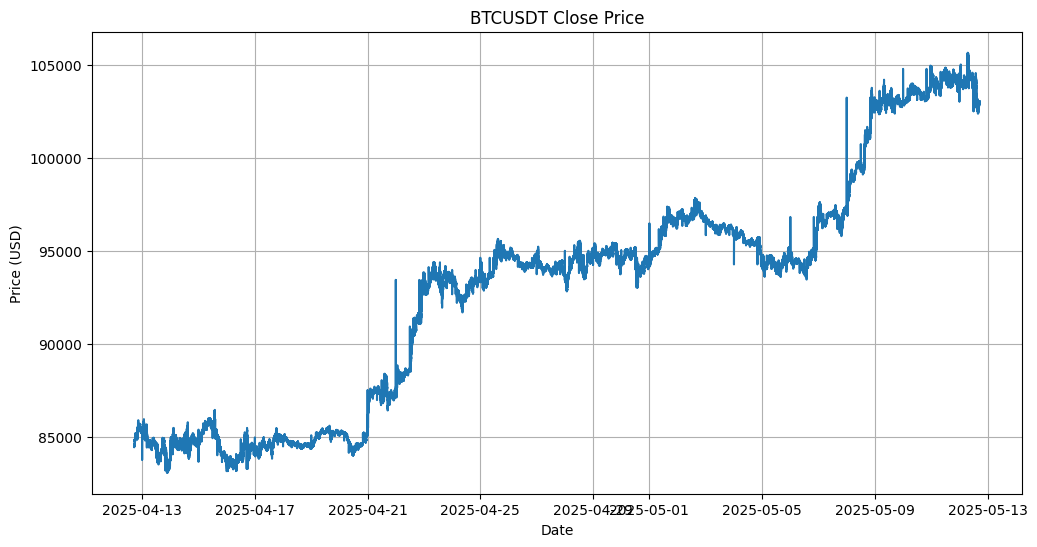

In [8]:
# Display data info
print(f"DataFrame shape: {df_bars.shape}")
print(f"Date range: {df_bars.index.min()} to {df_bars.index.max()}")

# Plot the close prices
plt.figure(figsize=(12, 6))
plt.plot(df_bars.index, df_bars["close"])
plt.title(f"{symbol} Close Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

## Configure and Run Backtest

Now we'll configure and run the backtest using the Moving Average Crossover strategy.

In [9]:
# Define the backtest configuration
config = BacktestEngineConfig(
    logging=LoggingConfig(log_level="INFO"),
    run_analysis=True,
)

# Create the backtest engine
engine = BacktestEngine(config=config)

# Add a trading venue first
engine.add_venue(
    venue=Venue("BINANCE"),
    oms_type=OmsType.NETTING,
    account_type=AccountType.MARGIN,
    base_currency=USD,
    starting_balances=[Money(1_000_000, USD)],
)

# Create the instrument using TestInstrumentProvider
instrument = TestInstrumentProvider.btcusdt_binance()

# Add the instrument
engine.add_instrument(instrument)

# Add the data directly (bars is a list of Bar objects)
engine.add_data(data=bars)

# Create the strategy configuration
strategy_config = MovingAverageCrossoverConfig(
    instrument_id=instrument_id,
    bar_type=bar_type,
    fast_ema_period=10,
    slow_ema_period=20,
    trade_size=Decimal("0.1"),
)

# Create and add the strategy
strategy = MovingAverageCrossover(config=strategy_config)
engine.add_strategy(strategy=strategy)

# Run the backtest
engine.run()

2025-05-13T02:19:32.996928340Z [INFO] BACKTESTER-001.BacktestEngine: Building system kernel
2025-05-13T02:19:32.997011006Z [INFO] BACKTESTER-001.MessageBus: config.database=None
2025-05-13T02:19:32.997017423Z [INFO] BACKTESTER-001.MessageBus: config.encoding='msgpack'
2025-05-13T02:19:32.997018423Z [INFO] BACKTESTER-001.MessageBus: config.timestamps_as_iso8601=False
2025-05-13T02:19:32.997018840Z [INFO] BACKTESTER-001.MessageBus: config.buffer_interval_ms=None
2025-05-13T02:19:32.997019798Z [INFO] BACKTESTER-001.MessageBus: config.autotrim_mins=None
2025-05-13T02:19:32.997020423Z [INFO] BACKTESTER-001.MessageBus: config.use_trader_prefix=True
2025-05-13T02:19:32.997021215Z [INFO] BACKTESTER-001.MessageBus: config.use_trader_id=True
2025-05-13T02:19:32.997021881Z [INFO] BACKTESTER-001.MessageBus: config.use_instance_id=False
2025-05-13T02:19:32.997023923Z [INFO] BACKTESTER-001.MessageBus: config.streams_prefix='stream'
2025-05-13T02:19:32.997024423Z [INFO] BACKTESTER-001.MessageBus: con

2025-04-14T06:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T06:00:00.000000000Z [ERROR] BACKTESTER-001.Portfolio: Cannot calculate account state: insufficient data for USDT/USD
2025-04-14T06:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T06:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T06:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T06:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-15T17:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-15T17:00:00.000000000Z [ERROR] BACKTESTER-001.Po

m
2025-04-16T15:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: [CMD]--> SubmitOrder(order=MarketOrder(BUY 0.100000 BTCUSDT.BINANCE MARKET GTC, status=INITIALIZED, client_order_id=O-20250416-150000-001-000-4, venue_order_id=None, position_id=None, tags=None), position_id=None)
2025-04-16T15:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: <--[EVT] OrderSubmitted(instrument_id=BTCUSDT.BINANCE, client_order_id=O-20250416-150000-001-000-4, account_id=BINANCE-001, ts_event=1744815600000000000)
2025-04-16T15:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: Closing 2 position with 1 order O-20250416-150000-001-000-4
2025-04-16T15:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: <--[EVT] OrderInitialized(instrument_id=BTCUSDT.BINANCE, client_order_id=O-20250416-150000-001-000-5, side=BUY, type=MARKET, quantity=0.100000, time_in_force=GTC, post_only=False, reduce_only=False, quote_quantity=False, options={}, emulation_trigger=NO_TRIGGER,

2025-04-24T05:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-24T05:00:00.000000000Z [ERROR] BACKTESTER-001.Portfolio: Cannot calculate account state: insufficient data for USDT/USD
2025-04-24T05:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-24T05:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-24T05:00:00.000000000Z [ERROR] BACKTESTER-001.Portfolio: Cannot calculate account state: insufficient data for USDT/USD
2025-04-24T05:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-24T05:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-24T05:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Can

t=1745132400000000000, ts_closed=0, duration_ns=0)
2025-04-20T23:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: Bullish crossover: Fast EMA 84830.0831 crossed above Slow EMA 84793.2081
2025-04-20T23:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: <--[EVT] OrderInitialized(instrument_id=BTCUSDT.BINANCE, client_order_id=O-20250420-230000-001-000-12, side=BUY, type=MARKET, quantity=0.100000, time_in_force=GTC, post_only=False, reduce_only=False, quote_quantity=False, options={}, emulation_trigger=NO_TRIGGER, trigger_instrument_id=None, contingency_type=NO_CONTINGENCY, order_list_id=None, linked_order_ids=None, parent_order_id=None, exec_algorithm_id=None, exec_algorithm_params=None, exec_spawn_id=None, tags=None)
2025-04-20T23:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: [CMD]--> SubmitOrder(order=MarketOrder(BUY 0.100000 BTCUSDT.BINANCE MARKET GTC, status=INITIALIZED, client_order_id=O-20250420-230000-001-000-12, venue_order_id=None, posit

culate exchange rate: ValueError('Quote maps must not be empty')
2025-04-28T06:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-28T06:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-28T17:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-28T17:00:00.000000000Z [ERROR] BACKTESTER-001.Portfolio: Cannot calculate account state: insufficient data for USDT/USD
2025-04-28T17:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-28T17:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-28T17:00:00.000000000Z [ERROR] BACKTESTER-001.Portfolio: Cannot calculate account state: insufficient data for USDT/USD

NCE net_position=0
2025-04-30T07:00:00.000000000Z [INFO] BACKTESTER-001.Portfolio: BTCUSDT.BINANCE margin_maint=0.00000000 USDT
2025-04-30T07:00:00.000000000Z [INFO] BACKTESTER-001.Portfolio: Updated AccountState(account_id=BINANCE-001, account_type=MARGIN, base_currency=USD, is_reported=False, balances=[AccountBalance(total=1_000_000.00 USD, locked=0.00 USD, free=1_000_000.00 USD)], margins=[], event_id=7735ec2f-79bd-40f8-b072-49ed58b5aeff)
2025-04-30T07:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: <--[EVT] OrderFilled(instrument_id=BTCUSDT.BINANCE, client_order_id=O-20250430-070000-001-000-38, venue_order_id=BINANCE-1-038, account_id=BINANCE-001, trade_id=BINANCE-1-25346, position_id=BTCUSDT.BINANCE-MovingAverageCrossover-000, order_side=SELL, order_type=MARKET, last_qty=0.100000, last_px=94_776.70 USDT, commission=9.47767000 USDT, liquidity_side=TAKER, ts_event=1745996400000000000)
2025-04-30T07:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: Order f

## Analyze Results

Now we'll analyze the results of the backtest.

In [10]:
# Get the performance statistics
performance = engine.trader.generate_account_report(Venue("BINANCE"))
print(performance)

                                total locked        free currency  \
2025-04-12 17:13:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-14 06:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-15 17:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-15 17:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-16 15:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-16 15:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-18 10:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-18 10:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-19 03:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-19 03:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-20 07:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-20 07:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-20 23:00:00+00:00  1000000.00   0.00  1000000.00      USD   
2025-04-20 23:00:00+00:00  1000000

In [11]:
# Get the order fills
order_fills = engine.trader.generate_order_fills_report()
order_fills.head()

,trader_id,strategy_id,instrument_id,venue_order_id,position_id,account_id,last_trade_id,type,side,quantity,...,order_list_id,linked_order_ids,parent_order_id,exec_algorithm_id,exec_algorithm_params,exec_spawn_id,tags,init_id,ts_init,ts_last
client_order_id,,,,,,,,,,,,,,,,,,,,,
O-20250414-060000-001-000-1,BACKTESTER-001,MovingAverageCrossover-000,BTCUSDT.BINANCE,BINANCE-1-001,BTCUSDT.BINANCE-MovingAverageCrossover-000,BINANCE-001,BINANCE-1-2209,MARKET,BUY,0.100000,...,None,None,None,None,None,None,None,c8319152-c184-4293-87f2-2f8673c2f137,2025-04-14 06:00:00+00:00,2025-04-14 06:00:00+00:00
O-20250415-170000-001-000-2,BACKTESTER-001,MovingAverageCrossover-000,BTCUSDT.BINANCE,BINANCE-1-002,BTCUSDT.BINANCE-MovingAverageCrossover-000,BINANCE-001,BINANCE-1-4310,MARKET,SELL,0.100000,...,None,None,None,None,None,None,None,29d72258-86f5-455f-ac9b-f83e3a59faa6,2025-04-15 17:00:00+00:00,2025-04-15 17:00:00+00:00
O-20250415-170000-001-000-3,BACKTESTER-001,MovingAverageCrossover-000,BTCUSDT.BINANCE,BINANCE-1-003,BTCUSDT.BINANCE-MovingAverageCrossover-000,BINANCE-001,BINANCE-1-4311,MARKET,SELL,0.100000,...,None,None,None,None,None,None,None,649c9ae9-4730-4d86-ba0e-2e1349df0fab,2025-04-15 17:00:00+00:00,2025-04-15 17:00:00+00:00
O-20250416-150000-001-000-4,BACKTESTER-001,MovingAverageCrossover-000,BTCUSDT.BINANCE,BINANCE-1-004,BTCUSDT.BINANCE-MovingAverageCrossover-000,BINANCE-001,BINANCE-1-5632,MARKET,BUY,0.100000,...,None,None,None,None,None,None,None,389b541b-3256-49c9-999c-2079b1b26b42,2025-04-16 15:00:00+00:00,2025-04-16 15:00:00+00:00
O-20250416-150000-001-000-5,BACKTESTER-001,MovingAverageCrossover-000,BTCUSDT.BINANCE,BINANCE-1-005,BTCUSDT.BINANCE-MovingAverageCrossover-000,BINANCE-001,BINANCE-1-5633,MARKET,BUY,0.100000,...,None,None,None,None,None,None,None,7dd8f411-1ac7-4cad-bede-e5c2ade47722,2025-04-16 15:00:00+00:00,2025-04-16 15:00:00+00:00


## Optimize Strategy Parameters

Now we'll optimize the strategy parameters to find the best combination of fast and slow EMA periods.

In [12]:
# Define the parameter ranges
fast_periods = range(5, 21, 5)  # 5, 10, 15, 20
slow_periods = range(20, 51, 10)  # 20, 30, 40, 50

# Initialize results storage
results = []

# Run backtests for each parameter combination
for fast_period in fast_periods:
    for slow_period in slow_periods:
        if fast_period >= slow_period:
            continue  # Skip invalid combinations
        
        print(f"Testing Fast EMA = {fast_period}, Slow EMA = {slow_period}")
        
        # Create a new engine for each backtest
        engine = BacktestEngine(config=config)
        
        # Add a trading venue
        engine.add_venue(
            venue=Venue("BINANCE"),
            oms_type=OmsType.NETTING,
            account_type=AccountType.MARGIN,
            base_currency=USD,
            starting_balances=[Money(1_000_000, USD)],
        )
        
        # Add the instrument
        engine.add_instrument(instrument)
        
        # Add the data
        engine.add_data(data=bars)
        
        # Create the strategy with the current parameters
        strategy_config = MovingAverageCrossoverConfig(
            instrument_id=instrument_id,
            bar_type=bar_type,
            fast_ema_period=fast_period,
            slow_ema_period=slow_period,
            trade_size=Decimal("0.1"),
        )
        
        strategy = MovingAverageCrossover(config=strategy_config)
        engine.add_strategy(strategy=strategy)
        
        # Run the backtest
        engine.run()
        
        # Get the performance statistics
        performance = engine.trader.generate_account_report(Venue("BINANCE"))
        
        # Store the results
        results.append({
            "fast_period": fast_period,
            "slow_period": slow_period,
            "return": performance.return_pct,
            "sharpe": performance.sharpe_ratio,
            "max_drawdown": performance.max_drawdown_pct,
            "win_rate": performance.win_rate,
        })
        
        print(f"Completed backtest: Fast EMA = {fast_period}, Slow EMA = {slow_period}, Return = {performance.return_pct:.2f}%")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df.sort_values(by="return", ascending=False, inplace=True)
results_df.head(10)

Testing Fast EMA = 5, Slow EMA = 20
2025-05-13T02:19:34.022178549Z [INFO] BACKTESTER-001.BacktestEngine: Building system kernel
2025-05-13T02:19:34.022201882Z [INFO] BACKTESTER-001.MessageBus: config.database=None
2025-05-13T02:19:34.022202632Z [INFO] BACKTESTER-001.MessageBus: config.encoding='msgpack'
2025-05-13T02:19:34.022203757Z [INFO] BACKTESTER-001.MessageBus: config.timestamps_as_iso8601=False
2025-05-13T02:19:34.022204465Z [INFO] BACKTESTER-001.MessageBus: config.buffer_interval_ms=None
2025-05-13T02:19:34.022204924Z [INFO] BACKTESTER-001.MessageBus: config.autotrim_mins=None
2025-05-13T02:19:34.022205299Z [INFO] BACKTESTER-001.MessageBus: config.use_trader_prefix=True
2025-05-13T02:19:34.022205590Z [INFO] BACKTESTER-001.MessageBus: config.use_trader_id=True
2025-05-13T02:19:34.022205840Z [INFO] BACKTESTER-001.MessageBus: config.use_instance_id=False
2025-05-13T02:19:34.022206382Z [INFO] BACKTESTER-001.MessageBus: config.streams_prefix='stream'
2025-05-13T02:19:34.022206715Z [

2025-04-14T02:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T02:00:00.000000000Z [ERROR] BACKTESTER-001.Portfolio: Cannot calculate account state: insufficient data for USDT/USD
2025-04-14T02:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T02:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T02:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T02:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T16:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T16:00:00.000000000Z [ERROR] BACKTESTER-001.Po

0 USDT, ts_opened=1744596000000000000, ts_last=1744646400000000000, ts_closed=1744646400000000000, duration_ns=50400000000000)
2025-04-14T16:00:00.000000000Z [INFO] BACKTESTER-001.Portfolio: BTCUSDT.BINANCE margin_init=0.00000000 USDT
2025-04-14T16:00:00.000000000Z [INFO] BACKTESTER-001.Portfolio: BTCUSDT.BINANCE net_position=-0.100000
2025-04-14T16:00:00.000000000Z [INFO] BACKTESTER-001.Portfolio: Updated AccountState(account_id=BINANCE-001, account_type=MARGIN, base_currency=USD, is_reported=False, balances=[AccountBalance(total=1_000_000.00 USD, locked=0.00 USD, free=1_000_000.00 USD)], margins=[], event_id=593aecd7-412f-493c-b377-ab11315a1489)
2025-04-14T16:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: <--[EVT] OrderFilled(instrument_id=BTCUSDT.BINANCE, client_order_id=O-20250414-160000-001-000-3, venue_order_id=BINANCE-1-003, account_id=BINANCE-001, trade_id=BINANCE-1-2811, position_id=BTCUSDT.BINANCE-MovingAverageCrossover-000, order_side=SELL, order_type=MARKET,

04-14T17:00:00.000000000Z [ERROR] BACKTESTER-001.Portfolio: Cannot calculate account state: insufficient data for USDT/USD
2025-04-14T17:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T17:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T17:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T17:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T23:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-04-14T23:00:00.000000000Z [ERROR] BACKTESTER-001.Portfolio: Cannot calculate account state: insufficient data for USDT/USD
2025-04-14T23:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot c

000000-001-000-9, venue_order_id=None, position_id=None, tags=None), position_id=None)
2025-04-15T00:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: <--[EVT] OrderSubmitted(instrument_id=BTCUSDT.BINANCE, client_order_id=O-20250415-000000-001-000-9, account_id=BINANCE-001, ts_event=1744675200000000000)
2025-04-15T00:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: Opening 1 position with order O-20250415-000000-001-000-9
2025-04-15T00:00:00.000000000Z [INFO] BACKTESTER-001.Portfolio: BTCUSDT.BINANCE margin_init=0.00000000 USDT
2025-04-15T00:00:00.000000000Z [INFO] BACKTESTER-001.Portfolio: BTCUSDT.BINANCE net_position=0
2025-04-15T00:00:00.000000000Z [INFO] BACKTESTER-001.Portfolio: BTCUSDT.BINANCE margin_maint=0.00000000 USDT
2025-04-15T00:00:00.000000000Z [INFO] BACKTESTER-001.Portfolio: Updated AccountState(account_id=BINANCE-001, account_type=MARGIN, base_currency=USD, is_reported=False, balances=[AccountBalance(total=1_000_000.00 USD, locked=0.00 USD, f

...

AttributeError: 'DataFrame' object has no attribute 'return_pct'

nue_order_id=BINANCE-1-047, account_id=BINANCE-001, trade_id=BINANCE-1-23795, position_id=BTCUSDT.BINANCE-MovingAverageCrossover-000, order_side=SELL, order_type=MARKET, last_qty=0.100000, last_px=94_382.71 USDT, commission=9.43827100 USDT, liquidity_side=TAKER, ts_event=1745902800000000000)
2025-04-29T05:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: Order filled: O-20250429-050000-001-000-47 0.100000 @ 94382.71
2025-04-29T05:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: <--[EVT] PositionOpened(instrument_id=BTCUSDT.BINANCE, position_id=BTCUSDT.BINANCE-MovingAverageCrossover-000, account_id=BINANCE-001, opening_order_id=O-20250429-050000-001-000-47, closing_order_id=None, entry=SELL, side=SHORT, signed_qty=-0.1, quantity=0.100000, peak_qty=0.100000, currency=USDT, avg_px_open=94382.71, avg_px_close=0.0, realized_return=0.00000, realized_pnl=-9.43827100 USDT, unrealized_pnl=0.00000000 USDT, ts_opened=1745902800000000000, ts_last=1745902800000000000, ts_

2025-05-10T18:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-10T18:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-10T18:00:00.000000000Z [ERROR] BACKTESTER-001.Portfolio: Cannot calculate account state: insufficient data for USDT/USD
2025-05-10T18:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-10T18:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-10T18:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-10T18:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-10T21:00:00.000000000Z [ERROR] BACKTESTER-001.Ca

_order_id=O-20250430-070000-001-000-55, side=SELL, type=MARKET, quantity=0.100000, time_in_force=GTC, post_only=False, reduce_only=False, quote_quantity=False, options={}, emulation_trigger=NO_TRIGGER, trigger_instrument_id=None, contingency_type=NO_CONTINGENCY, order_list_id=None, linked_order_ids=None, parent_order_id=None, exec_algorithm_id=None, exec_algorithm_params=None, exec_spawn_id=None, tags=None)
2025-04-30T07:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: [CMD]--> SubmitOrder(order=MarketOrder(SELL 0.100000 BTCUSDT.BINANCE MARKET GTC, status=INITIALIZED, client_order_id=O-20250430-070000-001-000-55, venue_order_id=None, position_id=None, tags=None), position_id=None)
2025-04-30T07:00:00.000000000Z [INFO] BACKTESTER-001.MovingAverageCrossover: <--[EVT] OrderSubmitted(instrument_id=BTCUSDT.BINANCE, client_order_id=O-20250430-070000-001-000-55, account_id=BINANCE-001, ts_event=1745996400000000000)
2025-04-30T07:00:00.000000000Z [INFO] BACKTESTER-001.MovingAvera

2025-05-10T21:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-10T21:00:00.000000000Z [ERROR] BACKTESTER-001.Portfolio: Cannot calculate account state: insufficient data for USDT/USD
2025-05-10T21:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-10T21:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-10T21:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-10T21:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-12T02:00:00.000000000Z [ERROR] BACKTESTER-001.Cache: Cannot calculate exchange rate: ValueError('Quote maps must not be empty')
2025-05-12T02:00:00.000000000Z [ERROR] BACKTESTER-001.Po

In [ ]:
# Plot the results
plt.figure(figsize=(12, 8))

# Create a pivot table for the heatmap
heatmap_data = results_df.pivot(index="fast_period", columns="slow_period", values="return")

# Plot the heatmap
plt.imshow(heatmap_data, cmap="viridis", aspect="auto")
plt.colorbar(label="Return (%)")

# Set the tick labels
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

# Add labels and title
plt.xlabel("Slow EMA Period")
plt.ylabel("Fast EMA Period")
plt.title("Moving Average Crossover Strategy Returns")

# Add the values to the heatmap
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.1f}%", ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

## Conclusion

In this notebook, we've demonstrated how to backtest and optimize a Moving Average Crossover strategy using Nautilus Trader. We've seen how to:

1. Load and prepare data for backtesting
2. Configure and run a backtest
3. Analyze the results
4. Optimize strategy parameters

The best parameter combination based on our optimization is shown in the sorted results table above.